# Knowledge graph inspection

Inspects the Neo4j knowledge graph built by `construct_kg.py`. Requires the Neo4j
instance from `docker-compose.yml` to be running - this notebook only reads the graph.

Schema recap: `__Entity__` nodes (typed via an extra label) linked by extracted
relationships; `Document` chunks with `MENTIONS` edges into entities; a hierarchical
`__Community__` layer (`IN_COMMUNITY`) carrying Leiden communities and their LLM summaries.

Sections: overview -> entities -> entity relationships -> documents & mentions ->
communities -> sanity checks.

In [1]:
import os
import sys
import textwrap
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # config.py reads variable_definitions/ relative to the project root

from langchain_community.graphs import Neo4jGraph
from config import NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD, NEO4J_DATABASE

graph = Neo4jGraph(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD, NEO4J_DATABASE, refresh_schema=False)


def q(cypher, **params):
    return pd.DataFrame(graph.query(cypher, params=params))


HUE = "#2a78d6"


def style_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)

/tmp/ipykernel_809168/2019721536.py:18: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-neo4j package and should be used instead. To use it run `pip install -U :class:`~langchain-neo4j` and import as `from :class:`~langchain_neo4j import Neo4jGraph``.
  graph = Neo4jGraph(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD, NEO4J_DATABASE, refresh_schema=False)


## Overview

Node counts per label and relationship counts per type. Note the label counts overlap:
every entity carries both `__Entity__` and its extracted type label
(`baseEntityLabel=True` in construction).

In [2]:
labels = q("""
MATCH (n) UNWIND labels(n) AS label
RETURN label, count(*) AS nodes
ORDER BY nodes DESC
""")
rel_types = q("""
MATCH ()-[r]->()
RETURN type(r) AS rel_type, count(*) AS rels
ORDER BY rels DESC
""")
print(f"{labels['nodes'].sum()} label assignments, {rel_types['rels'].sum()} relationships")
display(labels)
display(rel_types)

2134 label assignments, 3604 relationships


,label,nodes
0,__Entity__,697
1,__Community__,458
2,Person,107
3,Document,100
4,Author,57
...,...,...
230,Biological substance,1
231,Method,1
232,Ethnicity,1
233,Painmeasure,1


,rel_type,rels
0,MENTIONS,1299
1,IN_COMMUNITY,1024
2,ASSOCIATION,156
3,CO-AUTHOR,67
4,STUDY_SUBJECT,47
...,...,...
328,COUNTRY_FINANCIAL_RELATIONSHIP,1
329,AGE_FINANCIAL_RELATIONSHIP,1
330,FINANCIAL_LEVEL_GEOGRAPHICAL_RELATIONSHIP,1
331,CAUSEDBY,1


## Entities

Counts, property coverage (description / embedding / community assignment), and the
degree distribution over entity-entity edges only (`MENTIONS` and `IN_COMMUNITY`
excluded). High-degree entities are the graph's hubs; degree-0 entities were extracted
but never related to anything.

In [3]:
coverage = q("""
MATCH (e:__Entity__)
RETURN count(e) AS entities,
       sum(CASE WHEN e.description IS NOT NULL THEN 1 ELSE 0 END) AS with_description,
       sum(CASE WHEN e.embedding IS NOT NULL THEN 1 ELSE 0 END) AS with_embedding,
       sum(CASE WHEN e.communities IS NOT NULL THEN 1 ELSE 0 END) AS with_communities
""")
coverage

,entities,with_description,with_embedding,with_communities
0,697,654,697,697


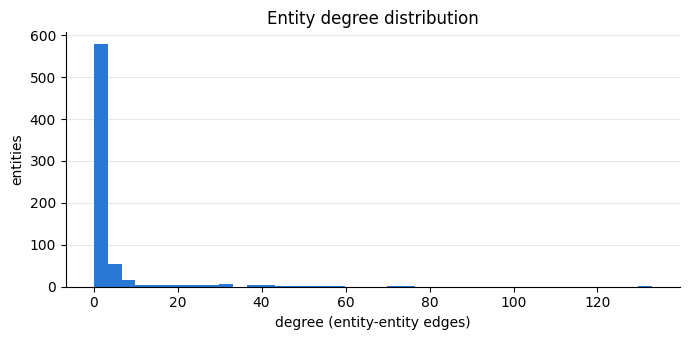

median degree 1, max 133, 84 isolated entities


,entity,degree
0,Alcohol,133
1,Depression,75
2,Age,70
3,Anxiety,57
4,Obesity,54
5,Pe_Score,51
6,Sleep Disturbance,49
7,Promis Depression,44
8,Promis Anxiety,44
9,Chronic Lower Back Pain,42


In [4]:
degrees = q("""
MATCH (e:__Entity__)
OPTIONAL MATCH (e)-[r]-(:__Entity__)
RETURN e.id AS entity, count(r) AS degree
ORDER BY degree DESC
""")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(degrees["degree"], bins=40, color=HUE)
ax.set_xlabel("degree (entity-entity edges)")
ax.set_ylabel("entities")
ax.set_title("Entity degree distribution")
style_axes(ax)
plt.tight_layout()
plt.show()

isolated = int((degrees["degree"] == 0).sum())
print(f"median degree {degrees['degree'].median():.0f}, max {degrees['degree'].max()}, "
      f"{isolated} isolated entities")
degrees.head(15)

## Entity-entity relationships

Which extracted relationship types dominate, plus a random sample of triplets to
eyeball extraction quality.

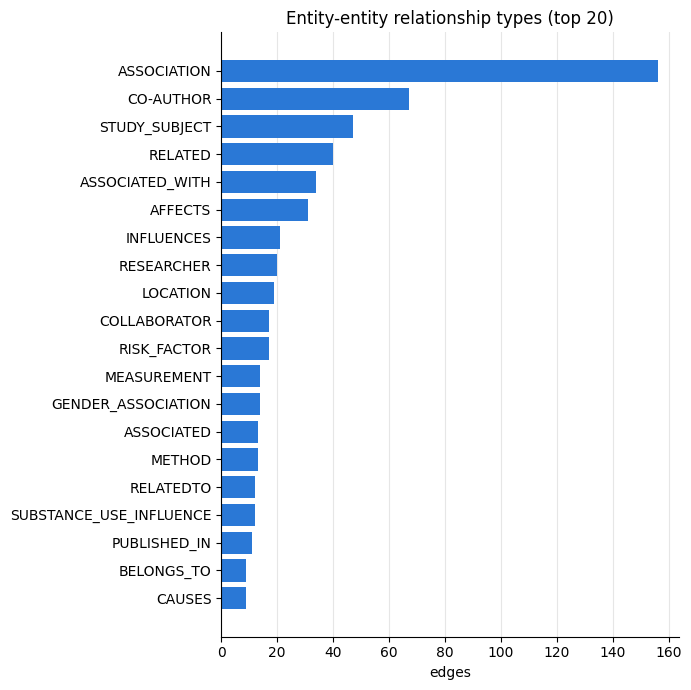

331 distinct relationship types


In [5]:
entity_rels = q("""
MATCH (:__Entity__)-[r]->(:__Entity__)
RETURN type(r) AS rel_type, count(*) AS n
ORDER BY n DESC
""")

top = entity_rels.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 0.3 * len(top) + 1))
ax.barh(top["rel_type"], top["n"], color=HUE)
ax.set_xlabel("edges")
ax.set_title("Entity-entity relationship types (top 20)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="0.9", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"{len(entity_rels)} distinct relationship types")

In [6]:
q("""
MATCH (a:__Entity__)-[r]->(b:__Entity__)
RETURN a.id AS source, type(r) AS rel_type, b.id AS target, r.description AS description
ORDER BY rand()
LIMIT 10
""")

,source,rel_type,target,description
0,Researchers,CONDUCTED,Genome-Wide Association Study,Researchers conducted the Genome-wide Associat...
1,0.289%,PERCENTAGE_AGE,>=65 Years,The percentage of 0.289% is associated with th...
2,Age,AGE_INFLUENCE,Promis Depression,Age can potentially influence the mental healt...
3,Males,GENDER_ASSOCIATION,Fear Avoidance,Fear avoidance is associated with the male gen...
4,Cci,COMORBIDITY_ASSOCIATION,Females,CCI is associated with the female gender.
5,Sex,SUBCATEGORY,Women,Women is a subcategory of the gender entity
6,Hinderliter,COLLABORATOR,Watkins,Both are researchers involved in the same study
7,2019,STUDY_PUBLICATION,18(1),The study was published as 18(1)
8,Mendelian Randomization,RESEARCH_METHOD,Coronary Artery Disease,Mendelian Randomization is the research method...
9,Education,EDUCATION_ASSOCIATION,Females,Education level is associated with the female ...


## Documents and MENTIONS

`Document` nodes are the ~600-token source chunks. Entities-per-chunk shows how dense
extraction was; chunks-per-entity shows which entities the corpus keeps coming back to
(this also drives `community_rank`).

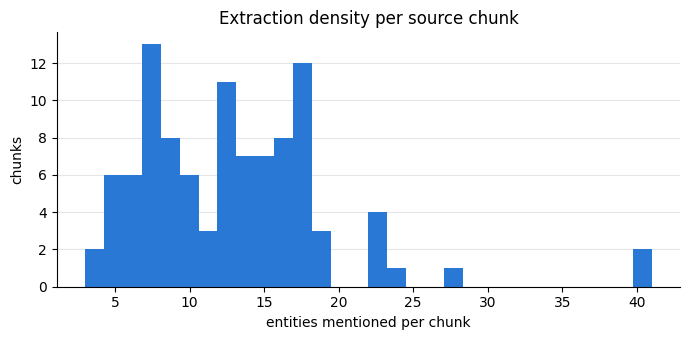

100 document chunks, median 13 entities per chunk, 0 chunks with no mentions


In [7]:
ents_per_doc = q("""
MATCH (d:Document)
OPTIONAL MATCH (d)-[:MENTIONS]->(e:__Entity__)
RETURN d.id AS doc, count(e) AS entities
""")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(ents_per_doc["entities"], bins=30, color=HUE)
ax.set_xlabel("entities mentioned per chunk")
ax.set_ylabel("chunks")
ax.set_title("Extraction density per source chunk")
style_axes(ax)
plt.tight_layout()
plt.show()

print(f"{len(ents_per_doc)} document chunks, "
      f"median {ents_per_doc['entities'].median():.0f} entities per chunk, "
      f"{int((ents_per_doc['entities'] == 0).sum())} chunks with no mentions")

In [8]:
q("""
MATCH (e:__Entity__)<-[:MENTIONS]-(d:Document)
RETURN e.id AS entity, count(DISTINCT d) AS chunks
ORDER BY chunks DESC
LIMIT 15
""")

,entity,chunks
0,Alcohol,35
1,Anxiety,33
2,Age,28
3,Depression,26
4,Obesity,25
5,Bmi,24
6,Overweight,22
7,Fear Avoidance,22
8,Financial Level,22
9,Sleep Disturbance,22


## Communities

The Leiden hierarchy: community counts and summary coverage per level, the size
distribution, and the top communities by `community_rank` (number of distinct source
chunks under the community). Singleton communities are never summarized, so summary
coverage is only expected for sizes > 1.

In [9]:
sizes = q("""
MATCH (c:__Community__)
OPTIONAL MATCH (c)<-[:IN_COMMUNITY*]-(e:__Entity__)
RETURN c.id AS community, c.level AS level, count(DISTINCT e) AS entities,
       c.summary IS NOT NULL AS has_summary
""")

per_level = sizes.groupby("level").agg(
    communities=("community", "count"),
    with_summary=("has_summary", "sum"),
    multi_entity=("entities", lambda s: int((s > 1).sum())),
    median_size=("entities", "median"),
    max_size=("entities", "max"),
)
per_level

,communities,with_summary,multi_entity,median_size,max_size
level,,,,,
0,188,104,104,2.0,61
1,139,55,55,1.0,103
2,131,47,47,1.0,118


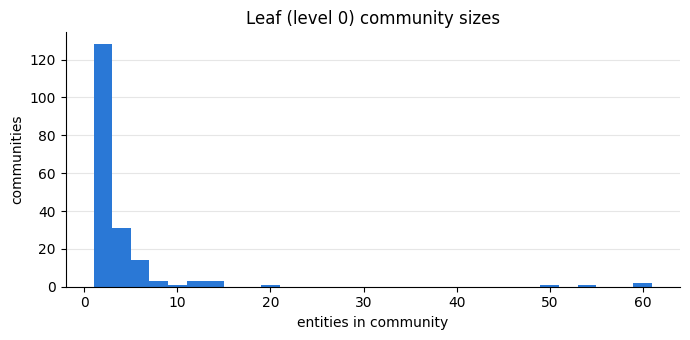

84 of 188 leaf communities are singletons


In [10]:
leaf = sizes[sizes["level"] == 0]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(leaf["entities"], bins=30, color=HUE)
ax.set_xlabel("entities in community")
ax.set_ylabel("communities")
ax.set_title("Leaf (level 0) community sizes")
style_axes(ax)
plt.tight_layout()
plt.show()

print(f"{int((leaf['entities'] == 1).sum())} of {len(leaf)} leaf communities are singletons")

In [11]:
top_communities = q("""
MATCH (c:__Community__)
WHERE c.community_rank IS NOT NULL
RETURN c.id AS community, c.level AS level, c.title AS title,
       c.community_rank AS rank, c.impact_severity_rating AS severity
ORDER BY rank DESC
LIMIT 10
""")
top_communities

,community,level,title,rank,severity
0,2-80,2,"Mental Health, Diabetes, and Cardiovascular Di...",53,7.5
1,1-59,1,"Mental Health, Diabetes, and Cardiovascular Di...",53,7.5
2,2-86,2,Chronic Lower Back Pain Community in Slovakia:...,49,7.5
3,1-4,1,Chronic Lower Back Pain Community in Slovakia:...,49,7.5
4,0-430,0,Chronic Lower Back Pain Community in Slovakia:...,48,7.5
5,1-6,1,Alcohol Consumption and Health Outcomes Community,44,8.5
6,2-39,2,Alcohol Consumption and Health Outcomes Community,44,8.5
7,0-640,0,Alcohol Consumption and Health Outcomes Community,39,8.5
8,0-590,0,"Mental Health, Diabetes, and Cardiovascular Di...",35,7.5
9,0-591,0,Adolescent Anxiety and Cardiovascular Health C...,33,7.5


In [12]:
# full report for the highest-ranked community that has a summary
sample = graph.query("""
MATCH (c:__Community__)
WHERE c.summary IS NOT NULL AND c.community_rank IS NOT NULL
RETURN c.id AS id, c.title AS title, c.summary AS summary
ORDER BY c.community_rank DESC
LIMIT 1
""")
if sample:
    s = sample[0]
    print(f"{s['id']}: {s['title']}\n")
    print(textwrap.fill(s["summary"] or "", width=100))
else:
    print("no summarized communities found")

1-59: Mental Health, Diabetes, and Cardiovascular Disease Community

This report examines the relationships between mental health, specifically depression and
neuroticism, diabetes, and cardiovascular disease (CAD). The analysis is based on a study that used
genome-wide association studies (GWAS) to investigate the genetic liability to depression and its
association with CAD in patients with diabetes. The study also explores the relationship between
depression and diabetes treatment nonadherence, and the influence of depression on various
cardiovascular outcomes.


## Sanity checks

Structural problems that would silently degrade retrieval: entities outside the
community hierarchy, entities no document mentions, and multi-entity communities
that never got a summary.

In [13]:
checks = {
    "entities not in any community": """
        MATCH (e:__Entity__) WHERE NOT (e)-[:IN_COMMUNITY]->() RETURN count(e) AS n
    """,
    "entities never mentioned by a document": """
        MATCH (e:__Entity__) WHERE NOT (e)<-[:MENTIONS]-(:Document) RETURN count(e) AS n
    """,
    "multi-entity communities without a summary": """
        MATCH (c:__Community__)<-[:IN_COMMUNITY*]-(e:__Entity__)
        WITH c, count(DISTINCT e) AS n
        WHERE n > 1 AND c.summary IS NULL
        RETURN count(c) AS n
    """,
}

problems = {name: graph.query(cy)[0]["n"] for name, cy in checks.items()}
flagged = {name: n for name, n in problems.items() if n}
if flagged:
    display(pd.Series(flagged, name="count").to_frame())
else:
    print("OK: all sanity checks passed")

,count
entities never mentioned by a document,43
